In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

print("Setup complete")

wine = load_wine()
X = wine.data # 13 measurements for each wine
y_true = wine.target # the real wine type: we hide this from the model

# TODO: print the shape of X to see how many wines and how many measurements
print("Shape of X:", X.shape)
print("Number of measurements:", len(wine.feature_names))

Setup complete
Shape of X: (178, 13)
Number of measurements: 13


In [2]:
# TODO: fit a StandardScaler on X and use it to transform X into X_scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling, first wine:", X[0][:3].round(2))
print("After scaling, first wine: ", X_scaled[0][:3].round(2))

Before scaling, first wine: [14.23  1.71  2.43]
After scaling, first wine:  [ 1.52 -0.56  0.23]


In [5]:
# TODO: create a KMeans model that looks for 3 clusters, then fit it on X_scaled
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

clusters = kmeans.labels_ # the group number that the model gave to each wine
print("First 20 group labels:", clusters[:20])
print("Wines in each group:", np.bincount(clusters))

First 20 group labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Wines in each group: [65 51 62]


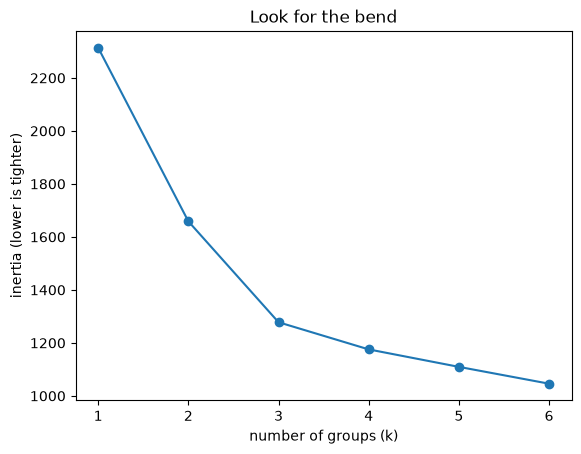

In [6]:
# TODO: for each k from 1 to 6, fit KMeans and store its inertia (tightness)
inertias = []
for k in range(1, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(range(1, 7), inertias, marker="o")
plt.xlabel("number of groups (k)")
plt.ylabel("inertia (lower is tighter)")
plt.title("Look for the bend")
plt.show()

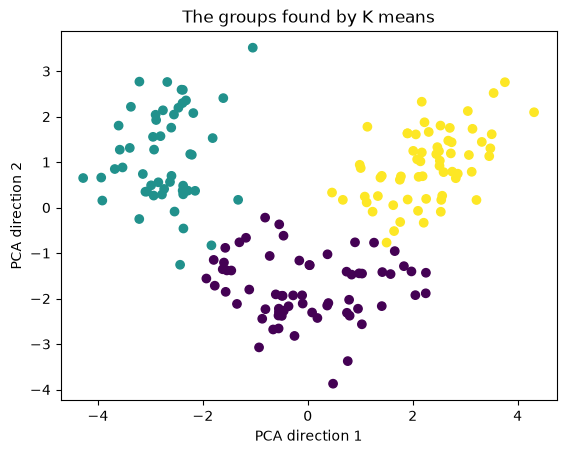

Part of the shape kept by 2 directions: 0.55


In [7]:
# TODO: use PCA to turn the 13 measurements into just 2, so we can plot them
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="viridis")
plt.xlabel("PCA direction 1")
plt.ylabel("PCA direction 2")
plt.title("The groups found by K means")
plt.show()

print("Part of the shape kept by 2 directions:", round(pca.explained_variance_ratio_.sum(), 2))

In [8]:
# A table: each row is a group the model found, each column is a true wine type
table = pd.crosstab(clusters, y_true, rownames=["group found"], colnames=["true type"])
print(table)

# TODO: compute the agreement score between the found groups and the true types
# adjusted_rand_score gives 1.0 for a perfect match and near 0.0 for random
score = adjusted_rand_score(y_true, clusters)
print("\nAgreement score (1.0 is perfect):", round(score, 3))

true type     0   1   2
group found            
0             0  65   0
1             0   3  48
2            59   3   0

Agreement score (1.0 is perfect): 0.897


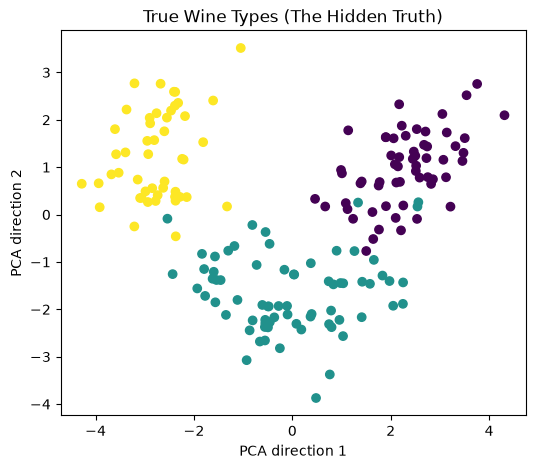

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()
X = wine.data
y_true = wine.target
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="viridis")
plt.xlabel("PCA direction 1")
plt.ylabel("PCA direction 2")
plt.title("True Wine Types (The Hidden Truth)")
plt.show()

In [2]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)
y_true = wine.target

for k_val in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init=10).fit(X_scaled)
    score = adjusted_rand_score(y_true, kmeans.labels_)
    print(f"Clusters (k={k_val}) | Agreement Score (ARI): {score:.3f}")

Clusters (k=2) | Agreement Score (ARI): 0.374
Clusters (k=3) | Agreement Score (ARI): 0.897
Clusters (k=4) | Agreement Score (ARI): 0.765
